# 🚢 Day 10 — Titanic Survival Prediction using Random Forest and XGBoost  
### Evaluating Ensemble Learning Algorithms on the Titanic Survival Prediction Task

A comparative study of Random Forest and XGBoost models to predict Titanic passenger survival, benchmarking their performance and interpretability.

---

## 1. Introduction


---

## 2. Project Objectives


---

## 3. Dataset Overview


---

## 4. Methodology and Approach


---

## 5. Tools and Libraries Used


---

## 6. Importing Libraries

In [124]:
# Core Libraries
import time
import warnings

# Data Manipulation 
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Saving
from joblib import dump

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

# XGBoost Imports
from xgboost import XGBClassifier
from xgboost import plot_tree, plot_importance

# Configurations
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---

## 7. Data Loading & Initial Exploration

Before model development, it is essential to **load and examine the dataset** to understand its structure and contents.  
This step includes importing the data, inspecting column types, identifying missing values, and reviewing basic statistics.  
Early exploration helps ensure the data is accurate, consistent, and suitable for further preprocessing and modeling.


#### Load the Dataset

In [5]:
titanic = sns.load_dataset("titanic")
print('Data Loaded!')
titanic.head()

Data Loaded!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### Copy the dataset

In [15]:
df = titanic.copy()

#### Dataset Shape

In [18]:
df.shape

(891, 15)

#### Dataset Information

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


#### Statistical Summary

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


#### Missing Values

In [27]:
print(df.isnull().sum().sum(), "missing values found.")

869 missing values found.


---

## 8. 

In [30]:
df = df.dropna(subset=['survived', 'sex'])

In [34]:
df['survived'] = df['survived'].astype(int)

---

## 9. 


In [36]:
num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['sex', 'class', 'embarked', 'who', 'adult_male', 'alone']

features = num_features + cat_features

In [38]:
X = df[features]
y = df['survived']

In [42]:
# Class balance
print("Class distribution:\n", y.value_counts(normalize=True))

Class distribution:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


---

## 10. 

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

---

## 11. 


In [46]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')  # drop other columns

---

## 12. 

In [50]:
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

pipe_xgb = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))
])

---

## 13. 

In [52]:
t0 = time.time()
pipe_rf.fit(X_train, y_train)
rf_train_time = time.time() - t0

In [54]:
t0 = time.time()
pipe_xgb.fit(X_train, y_train)
xgb_train_time = time.time() - t0

In [56]:
def evaluate(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    # For roc/PR we need probability for positive class
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        # Pipeline wraps estimator that has predict_proba
        y_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    return metrics, y_pred, y_prob

In [70]:
metrics_rf_base, ypred_rf_base, yprob_rf_base = evaluate(pipe_rf, X_test, y_test)
metrics_xgb_base, ypred_xgb_base, yprob_xgb_base = evaluate(pipe_xgb, X_test, y_test)

base_results = pd.DataFrame([
    {'model': 'RandomForest (baseline)', **metrics_rf_base, 'train_time_s': rf_train_time},
    {'model': 'XGBoost (baseline)', **metrics_xgb_base, 'train_time_s': xgb_train_time},
])
print("Baseline results:")
base_results

Baseline results:


,model,accuracy,precision,recall,f1,roc_auc,train_time_s
0,RandomForest (baseline),0.810056,0.769231,0.724638,0.746269,0.834717,0.182884
1,XGBoost (baseline),0.815642,0.764706,0.753623,0.759124,0.829381,0.056776


---

## 14. 

In [64]:
rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_dist = {
    'clf__n_estimators': [100, 200, 500],
    'clf__max_depth': [None, 6, 10, 20],
    'clf__min_samples_leaf': [1, 2, 5],
    'clf__max_features': ['sqrt', 'log2', 0.6]
}

xgb_param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [3, 6, 10],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0]
}

In [66]:
n_iter_search = 24

rs_rf = RandomizedSearchCV(pipe_rf, rf_param_dist, n_iter=n_iter_search, cv=rkf,
                           scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1)

rs_xgb = RandomizedSearchCV(pipe_xgb, xgb_param_dist, n_iter=n_iter_search, cv=rkf,
                            scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1)

print("Starting RF search...")
t0 = time.time()
rs_rf.fit(X_train, y_train)
rf_search_time = time.time() - t0
print("RF search done. Best params:", rs_rf.best_params_, "Best CV ROC-AUC:", rs_rf.best_score_)

print("\nStarting XGB search...")
t0 = time.time()
rs_xgb.fit(X_train, y_train)
xgb_search_time = time.time() - t0
print("XGB search done. Best params:", rs_xgb.best_params_, "Best CV ROC-AUC:", rs_xgb.best_score_)

best_rf = rs_rf.best_estimator_
best_xgb = rs_xgb.best_estimator_

Starting RF search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
RF search done. Best params: {'clf__n_estimators': 500, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.6, 'clf__max_depth': None} Best CV ROC-AUC: 0.8810739447769228

Starting XGB search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGB search done. Best params: {'clf__subsample': 0.6, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.6} Best CV ROC-AUC: 0.8880906768837804


---

## 15. 

In [72]:
metrics_rf_tuned, ypred_rf_tuned, yprob_rf_tuned = evaluate(best_rf, X_test, y_test)
metrics_xgb_tuned, ypred_xgb_tuned, yprob_xgb_tuned = evaluate(best_xgb, X_test, y_test)

tuned_results = pd.DataFrame([
    {'model': 'RandomForest (tuned)', **metrics_rf_tuned, 'search_time_s': rf_search_time},
    {'model': 'XGBoost (tuned)', **metrics_xgb_tuned, 'search_time_s': xgb_search_time},
])

print("Tuned results:")
tuned_results

Tuned results:


,model,accuracy,precision,recall,f1,roc_auc,search_time_s
0,RandomForest (tuned),0.821229,0.813559,0.695652,0.750000,0.846377,28.796006
1,XGBoost (tuned),0.810056,0.796610,0.681159,0.734375,0.844598,4.345734


In [74]:
summary = pd.concat([base_results, tuned_results], ignore_index=True)
print("Full summary:")
summary

Full summary:


,model,accuracy,precision,recall,f1,roc_auc,train_time_s,search_time_s
0,RandomForest (baseline),0.810056,0.769231,0.724638,0.746269,0.834717,0.182884,NaN
1,XGBoost (baseline),0.815642,0.764706,0.753623,0.759124,0.829381,0.056776,NaN
2,RandomForest (tuned),0.821229,0.813559,0.695652,0.750000,0.846377,NaN,28.796006
3,XGBoost (tuned),0.810056,0.796610,0.681159,0.734375,0.844598,NaN,4.345734


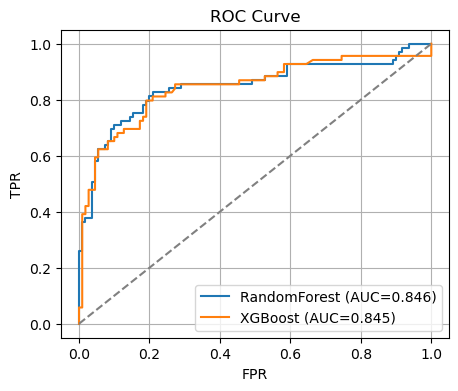

In [82]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, yprob_rf_tuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, yprob_xgb_tuned)

plt.figure(figsize=(5,4))
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={metrics_rf_tuned['roc_auc']:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={metrics_xgb_tuned['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.grid(True)
plt.show()

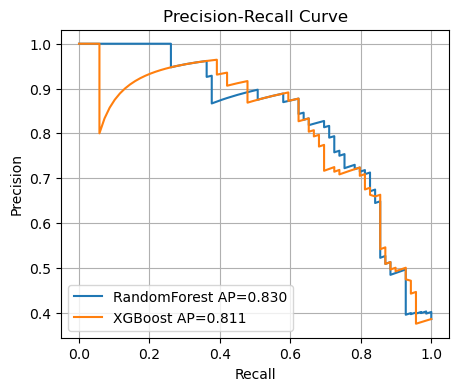

In [86]:
prec_rf, rec_rf, _ = precision_recall_curve(y_test, yprob_rf_tuned)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, yprob_xgb_tuned)

plt.figure(figsize=(5,4))
plt.plot(rec_rf, prec_rf, label=f"RandomForest AP={auc(rec_rf, prec_rf):.3f}")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost AP={auc(rec_xgb, prec_xgb):.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve"); plt.legend(); plt.grid(True)
plt.show()

In [120]:
print("Random Forest classification report (tuned):")
print(classification_report(y_test, ypred_rf_tuned))
print("Confusion matrix:\n", confusion_matrix(y_test, ypred_rf_tuned))
print('-'*60)
print("XGBoost classification report (tuned):")
print(classification_report(y_test, ypred_xgb_tuned))
print("Confusion matrix:\n", confusion_matrix(y_test, ypred_xgb_tuned))

Random Forest classification report (tuned):
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion matrix:
 [[99 11]
 [21 48]]
------------------------------------------------------------
XGBoost classification report (tuned):
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

Confusion matrix:
 [[98 12]
 [22 47]]


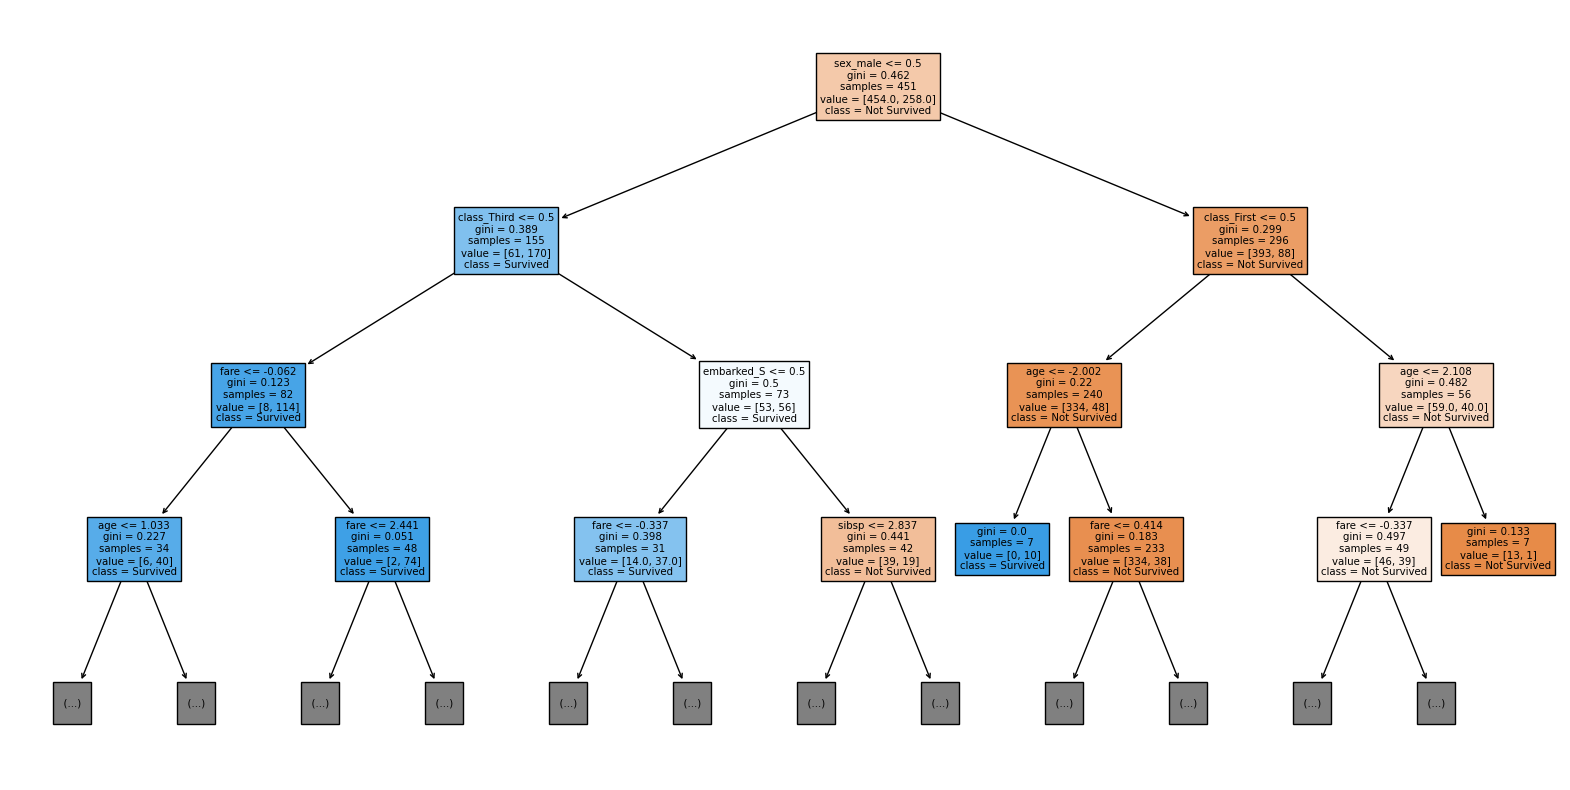

In [108]:
# Extract one tree from Random Forest
estimator = best_rf.named_steps['clf'].estimators_[0]

plt.figure(figsize=(20,10))
tree.plot_tree(
    estimator,
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    max_depth=3
)
plt.show()

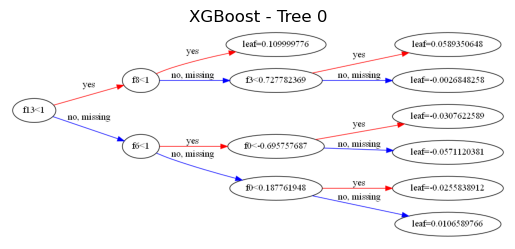

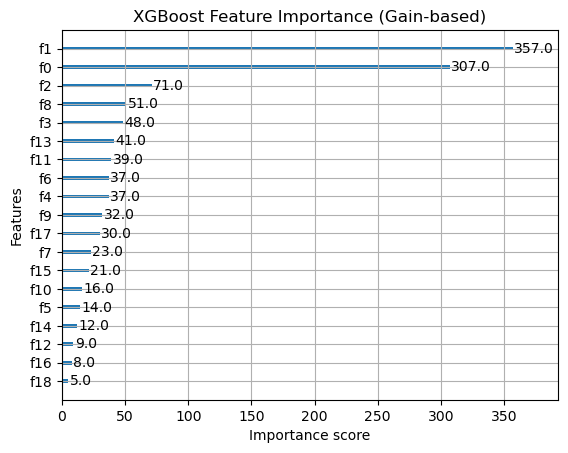

In [112]:
# Plot a single XGBoost tree
plot_tree(best_xgb.named_steps['clf'], num_trees=0, rankdir='LR')
plt.title("XGBoost - Tree 0")

# Plot top feature importance (built-in XGBoost version)
plot_importance(best_xgb.named_steps['clf'])
plt.title("XGBoost Feature Importance (Gain-based)")
plt.show()

---

## 16. Feature Importance & Threshold Tuning

In [88]:
prepped = preprocessor.fit(X_train)  # fit transformer alone to get column names
# build feature names after OneHotEncoder
ohe = prepped.named_transformers_['cat'].named_steps['onehot']
ohe_categories = ohe.get_feature_names_out(cat_features)
feature_names = np.concatenate([num_features, ohe_categories])

rf_clf = best_rf.named_steps['clf']
rf_importances = rf_clf.feature_importances_
rf_feat_imp = pd.DataFrame({'feature': feature_names, 'importance': rf_importances}).sort_values('importance', ascending=False)
print("Top 10 RF features:")
rf_feat_imp.head(10)

Top 10 RF features:


,feature,importance
1,fare,0.174470
15,adult_male_False,0.121898
13,who_man,0.120867
16,adult_male_True,0.109845
0,age,0.104850
8,class_Third,0.101456
5,sex_male,0.068024
4,sex_female,0.062001
2,sibsp,0.034586
6,class_First,0.031544


In [92]:
# Get preprocessed test data
X_test_prepared = best_xgb.named_steps['pre'].transform(X_test)

# Run permutation importance on the underlying XGBoost model
perm = permutation_importance(
    best_xgb.named_steps['clf'],
    X_test_prepared,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Match with one-hot expanded feature names
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print("Permutation importance (XGB):")
perm_df.head(10)

Permutation importance (XGB):


,feature,importance
13,who_man,0.056983
8,class_Third,0.047486
2,sibsp,0.024022
0,age,0.021788
16,adult_male_True,0.016201
15,adult_male_False,0.012291
10,embarked_Q,0.011173
1,fare,0.010615
4,sex_female,0.009497
11,embarked_S,0.007263


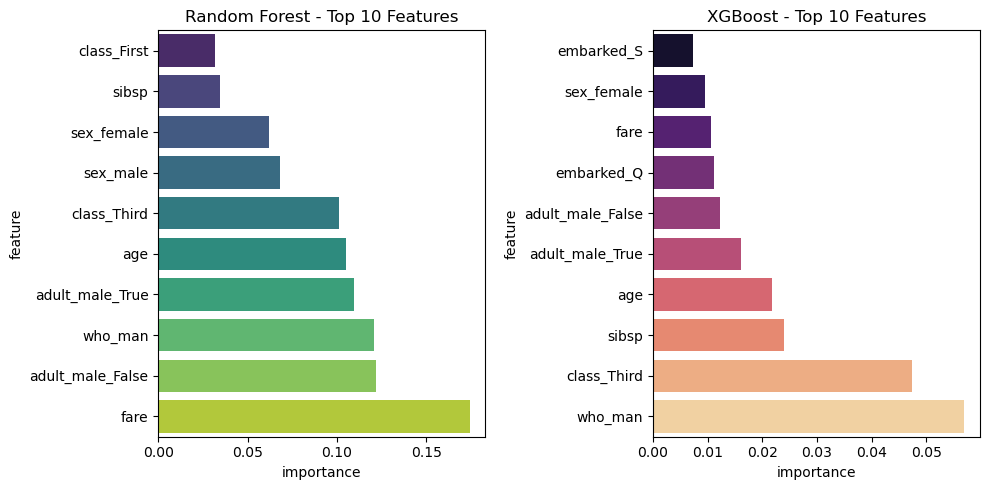

In [102]:
rf_importances = rf_feat_imp.sort_values('importance', ascending=True).tail(10)
xgb_importances = perm_df.sort_values('importance', ascending=True).tail(10)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(x='importance', y='feature', data=rf_importances, palette='viridis')
plt.title("Random Forest - Top 10 Features")

plt.subplot(1,2,2)
sns.barplot(x='importance', y='feature', data=xgb_importances, palette='magma')
plt.title("XGBoost - Top 10 Features")

plt.tight_layout()
plt.show()

---

## 17.

In [126]:
dump(best_rf, 'best_rf_titanic.joblib')
dump(best_xgb, 'best_xgb_titanic.joblib')
print('Models saved successfully!')

Models saved successfully!


---

## 18. 

----

## 19.